# SVI: fitting a well-behaved volatility smile

This notebook builds up the SVI (Stochastic Volatility Inspired) smile
parametrization from motivation through theory to a validated fitter, working
entirely on synthetic data where we control the ground truth. The final
section, fitting real CBOE quotes, is added separately once the machinery here
is trusted.

The order is deliberate: understand the object and its failure modes on data
we generate ourselves, so that when real market noise arrives we can tell a
data problem from a code problem.

## 1. The problem: from noisy quotes to a usable surface

The market gives us option quotes at a scatter of discrete strikes for one
expiry. Convert each to an implied volatility, then to *total implied variance*
$w = \sigma_{BS}^2\,\tau$, and plot against *log-moneyness* $k = \log(K/F)$.
The result is a point cloud, the "smile," and it is noisy, especially in the
illiquid wings.

We want a smooth curve threaded through that cloud. Three reasons, in
increasing order of importance:

1. **Denoising.** Downstream model calibration should fit clean signal, not
   bid-ask bounce and stale strikes.
2. **No-arbitrage.** Raw quotes, particularly in the wings, can be mutually
   inconsistent, implying negative probability densities. Calibrating a model
   straight to those asks it to fit prices no arbitrage-free model can produce.
   SVI gives a target that is guaranteed arbitrage-free.
3. **Continuity.** Quotes exist only at discrete strikes. A continuous curve
   lets us evaluate the market's implied variance at any $k$, which model
   calibration needs.

So the goal is a smooth, arbitrage-free, continuously-evaluable representation
of the smile. One caution to carry throughout: SVI can only produce shapes SVI
can produce, so if the fit systematically misses the same region on every
slice, that is real structure being discarded, not noise removed. Watch the
residual pattern, not just its size.

In [1]:
# Setup. Import the certified module and plotting.
import numpy as np
import matplotlib.pyplot as plt

from calibration.svi import (
    SVIParams,
    svi_raw,
    svi_raw_first,
    svi_raw_second,
    durrleman_g,
    fit_slice,
    verify_fit,
    fit_surface,
    calendar_violation
)

# A representative equity-smile slice, used throughout as our ground truth.
# Negative rho and m reflect real equity skew (left wing steeper, vertex just
# below the money).
TRUE = SVIParams(a=0.04, b=0.4, rho=-0.3, m=-0.05, sigma=0.15)

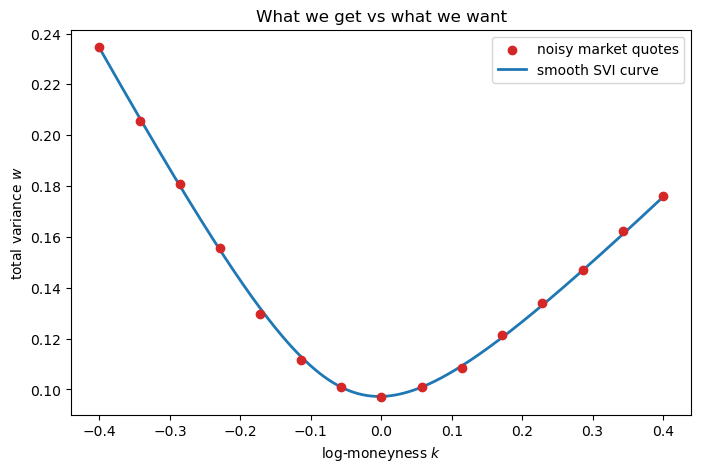

In [2]:
# Illustrate reason 1: a jagged "market" smile vs the clean SVI curve.
rng = np.random.default_rng(42)  # seeded, reproducible

k_quotes = np.linspace(-0.4, 0.4, 15)
w_true = svi_raw(k_quotes, TRUE)
w_noisy = w_true + rng.normal(0.0, 1e-3, size=k_quotes.shape)  # quote noise in w

k_dense = np.linspace(-0.4, 0.4, 400)
w_curve = svi_raw(k_dense, TRUE)

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(k_quotes, w_noisy, color="tab:red", zorder=3, label="noisy market quotes")
ax.plot(k_dense, w_curve, color="tab:blue", lw=2, label="smooth SVI curve")
ax.set_xlabel("log-moneyness $k$")
ax.set_ylabel("total variance $w$")
ax.set_title("What we get vs what we want")
ax.legend()
plt.show()

**Note:** The synthetic noise is gentler than reality. We illustrate the ideal case for SVI fitting.

## 2. The parametrization

Raw SVI, per maturity slice, in total variance against log-moneyness:

$$w(k) = a + b\Big(\rho(k-m) + \sqrt{(k-m)^2 + \sigma^2}\Big)$$

Five parameters, each with a clean geometric role:

- $a$ shifts the whole slice vertically (the overall variance level).
- $b$ sets the angle between the two asymptotes (overall wing steepness).
- $\rho$ tilts the smile (the skew); negative $\rho$ makes the left wing steeper,
  which is the equity signature.
- $m$ translates the smile horizontally (where the vertex sits).
- $\sigma$ controls how rounded the vertex is; $\sigma \to 0$ gives a sharp kink
  at $k = m$.

As $k \to \pm\infty$ the curve is asymptotically linear, with slopes
$b(1+\rho)$ on the right and $b(1-\rho)$ on the left. That linearity is not
cosmetic: it is exactly what Lee's moment formula demands, that implied
variance grow at most linearly in $|k|$. SVI is built to respect that, which is
why extrapolating it into the wings does not blow up.

The name is worth taking literally. SVI is *inspired by* stochastic volatility
models (Gatheral showed the large-time Heston smile has this form) but there is
no SDE underneath. It is a static parametrization, a clean interpolant of one
day's quotes. It carries no dynamics, which is precisely why it serves as the
target that dynamic models like Heston and SABR calibrate against.

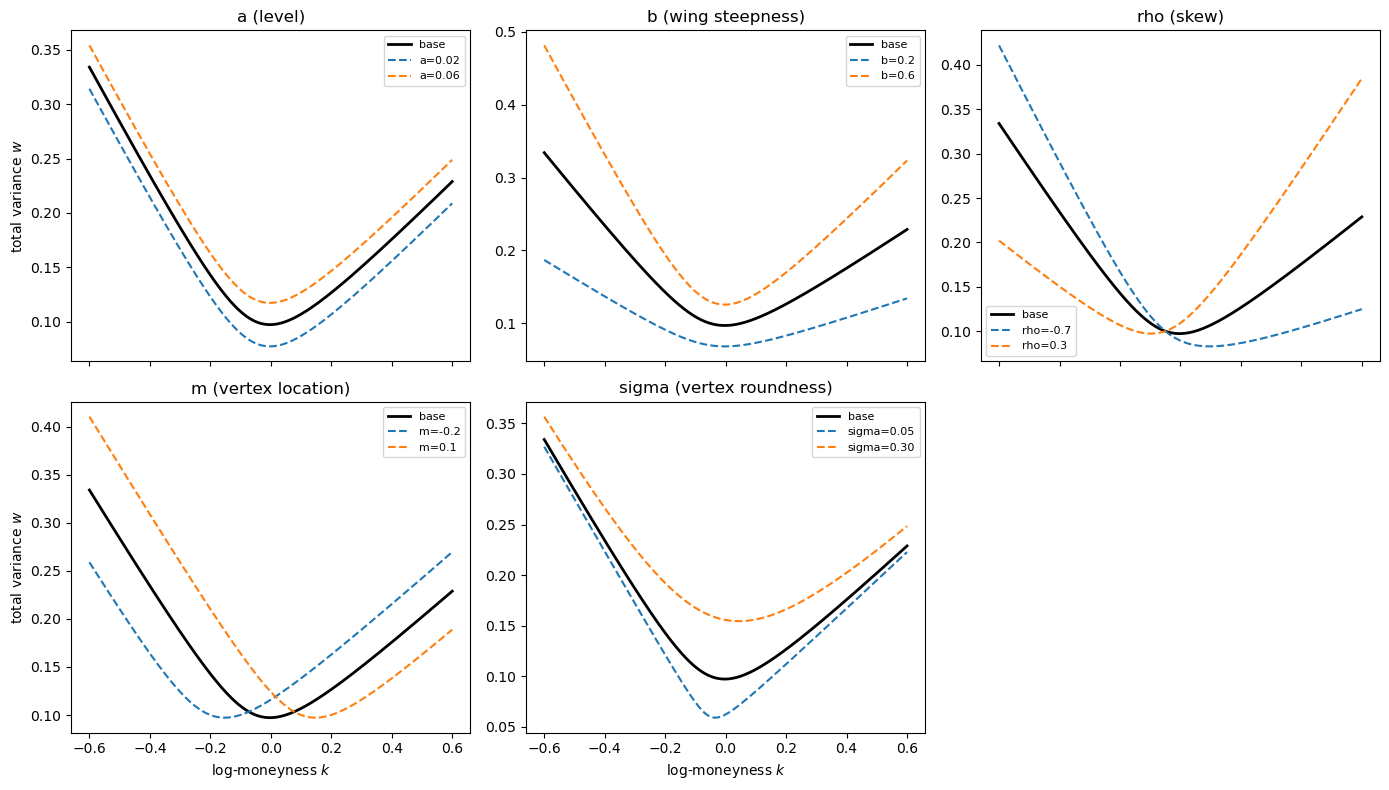

In [3]:
# Show each parameter moving, so a reader SEES its effect.
# Five small subplots (or a 2x3 grid). In each, plot the TRUE slice as a
# reference line, then overlay 2-3 variants with one parameter perturbed.

k_dense = np.linspace(-0.6, 0.6, 400)

fig, axes = plt.subplots(2, 3, figsize=(14, 8), sharex=True)

def panel(ax, title, variants):
    ax.plot(k_dense, svi_raw(k_dense, TRUE), color="black", lw=2, label="base")
    for lbl, p in variants:
        ax.plot(k_dense, svi_raw(k_dense, p), lw=1.5, ls="--", label=lbl)
    ax.set_title(title)
    ax.legend(fontsize=8)

# a: vertical shift
panel(axes[0, 0], "a (level)", [
    ("a=0.02", TRUE._replace(a=0.02)),
    ("a=0.06", TRUE._replace(a=0.06)),
])
# b: wing steepness
panel(axes[0, 1], "b (wing steepness)", [
    ("b=0.2", TRUE._replace(b=0.2)),
    ("b=0.6", TRUE._replace(b=0.6)),
])
# rho: tilt
panel(axes[0, 2], "rho (skew)", [
    ("rho=-0.7", TRUE._replace(rho=-0.7)),
    ("rho=0.3", TRUE._replace(rho=0.3)),
])
# m: horizontal shift
panel(axes[1, 0], "m (vertex location)", [
    ("m=-0.2", TRUE._replace(m=-0.2)),
    ("m=0.1", TRUE._replace(m=0.1)),
])
# sigma: vertex roundness
panel(axes[1, 1], "sigma (vertex roundness)", [
    ("sigma=0.05", TRUE._replace(sigma=0.05)),
    ("sigma=0.30", TRUE._replace(sigma=0.30)),
])

axes[1, 2].axis("off")  # spare panel
for ax in axes[1, :]:
    ax.set_xlabel("log-moneyness $k$")
for ax in axes[:, 0]:
    ax.set_ylabel("total variance $w$")
plt.tight_layout()
plt.show()

## 3. Why total variance, not implied vol

The choice of $w = \sigma_{BS}^2\tau$ over plain implied vol is not arbitrary.
The no-arbitrage conditions are natural in total variance.

Calendar arbitrage (roughly, that a longer-dated option cannot be worth less
than a shorter-dated one at the same moneyness) reduces in total variance to a
plain monotonicity condition: $w(k)$ must be non-decreasing in maturity
$\tau$. Total variance can only accumulate as you add time. In implied-vol
space that same condition is a messier expression and easy to implement wrong.

Log-moneyness against the *forward* (not spot) is the companion choice: it
centres each slice on the at-the-money-forward point and makes slices at
different maturities directly comparable.

## 4. Arbitrage within a slice, and the function that detects it

A curve can hug the quotes beautifully and still be illegal. Butterfly
arbitrage corresponds to a negative implied probability density, and a fit can
produce one in the wings while looking perfect near the money.

The density implied by a slice, written in log-moneyness, factors into a
strictly positive part times a single function Gatheral calls $g$:

$$g(k) = \left(1 - \frac{k\,w'}{2w}\right)^2
        - \frac{w'^2}{4}\left(\frac{1}{w} + \frac14\right)
        + \frac{w''}{2}$$

Because everything multiplying $g$ in the density is positive, **butterfly
arbitrage is exactly $g(k) < 0$**. One scalar function, a sign check.

Reading the three terms tells us where violations live. The first is a square,
always non-negative. For raw SVI the third is $w''/2 > 0$ everywhere. So only
the middle term can pull $g$ negative, and it does so where $w$ is small and
$w'$ is steep. That means short-dated slices on the steep put wing, not the far
wing. Two consequences we will use: fit the shortest maturities first (failures
surface before a surface is built on top of them), and check $g$ most densely
near the money.

The asymptotic version of the same condition recovers Lee's bound. As
$k \to \infty$, $g(\infty) = \tfrac14 - \tfrac{\beta^2}{16}$ with
$\beta = b(1+\rho)$, so $g \ge 0$ forces $b(1+\rho) \le 2$. The density
condition and the wing-slope bound are the same statement.

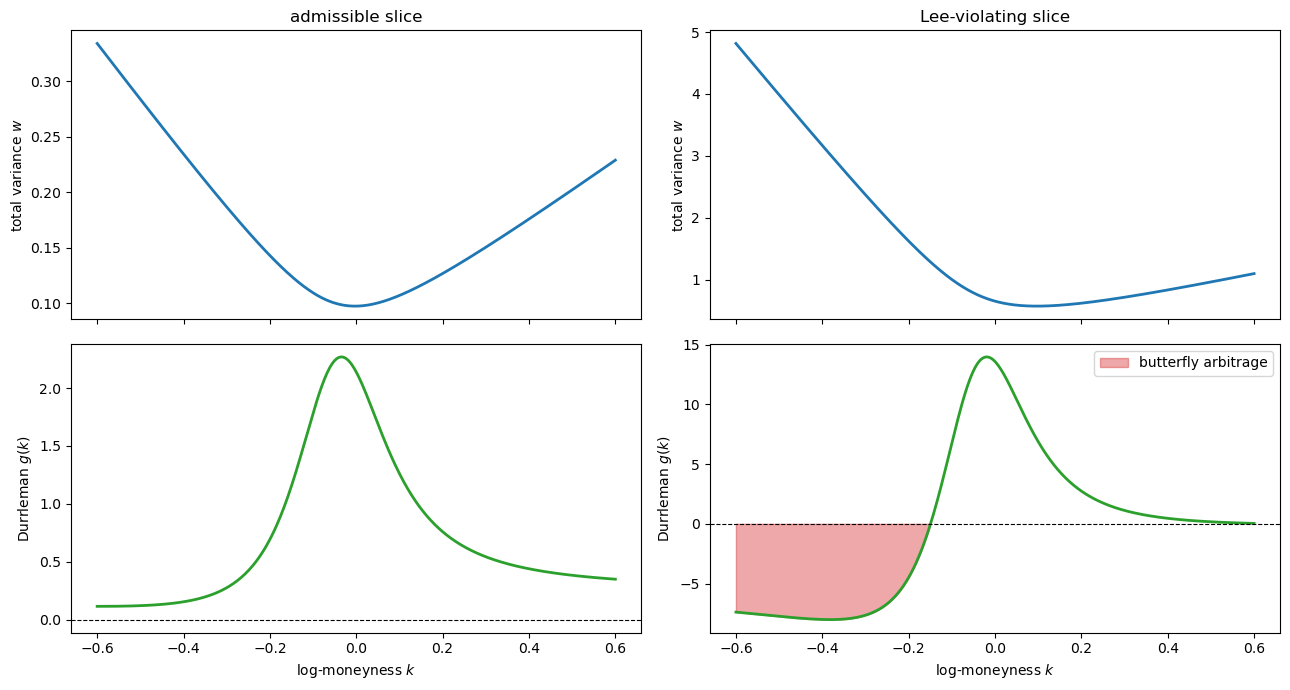

In [4]:
# Make the arbitrage check visual: a clean slice vs a broken one.
BROKEN = SVIParams(a=0.04, b=5.0, rho=-0.7, m=-0.05, sigma=0.15)
assert BROKEN.b * (1 + abs(BROKEN.rho)) > 2.0  # confirm it violates Lee

k_dense = np.linspace(-0.6, 0.6, 400)

fig, axes = plt.subplots(2, 2, figsize=(13, 7), sharex=True)

for col, (name, p) in enumerate([("admissible slice", TRUE), ("Lee-violating slice", BROKEN)]):
    w = svi_raw(k_dense, p)
    g = durrleman_g(k_dense, p)

    axes[0, col].plot(k_dense, w, color="tab:blue", lw=2)
    axes[0, col].set_title(name)
    axes[0, col].set_ylabel("total variance $w$")

    axes[1, col].plot(k_dense, g, color="tab:green", lw=2)
    axes[1, col].axhline(0.0, color="black", lw=0.8, ls="--")
    axes[1, col].fill_between(k_dense, g, 0.0, where=(g < 0.0),
                             color="tab:red", alpha=0.4, label="butterfly arbitrage")
    axes[1, col].set_ylabel("Durrleman $g(k)$")
    axes[1, col].set_xlabel("log-moneyness $k$")
    if np.any(g < 0.0):
        axes[1, col].legend()

plt.tight_layout()
plt.show()

The top-right $w$ curve looks like a perfectly innocent (if steep) smile, but the $g$ panel below it reveals the entire left wing is arbitrageable. That's the lesson, you cannot see butterfly arbitrage by looking at the smile, you have to compute $g$. Nice that the violation lands on the left wing too, consistent with $ρ$ =−0.7 making that side steepest, which is where the $w^{′2}$ term does its damage.

## 5. Fitting: the two-stage reduction

Fitting five parameters directly is hard because they are strongly correlated.
Near the money the data reveals only a level, a slope, and a curvature, three
observable combinations, while we are trying to pin down five parameters. In
particular $\{a, b, \sigma\}$ collapse onto about two of those combinations, and
a naive optimizer from a random start lands in local minima.

The Zeliade reduction unties the knot. Substitute $y = (k-m)/\sigma$ and rename
$c = b\sigma$, $d = \rho b\sigma$. Then

$$w = a + d\,y + c\sqrt{y^2+1}$$

which for *fixed* $(m,\sigma)$ is **linear** in $(a, d, c)$. So we split the
problem into two nested loops:

- **Inner**: given $(m,\sigma)$, solve for $(a,d,c)$ by constrained linear least
  squares. Fast, reliable, no local minima. The constraints ($b \ge 0$,
  $|\rho| \le 1$, $w \ge 0$, the Lee bound) are all linear in the reduced
  coordinates.
- **Outer**: search over just $(m,\sigma)$, two dimensions, with Nelder-Mead
  from several spread-out starts.

Five correlated dimensions become two clean geometric ones with a cheap exact
solve inside. The arbitrage penalty rides on the outer objective as a squared
hinge on $g$, so the inner problem stays linear while the search is steered
away from arbitrageable curves.

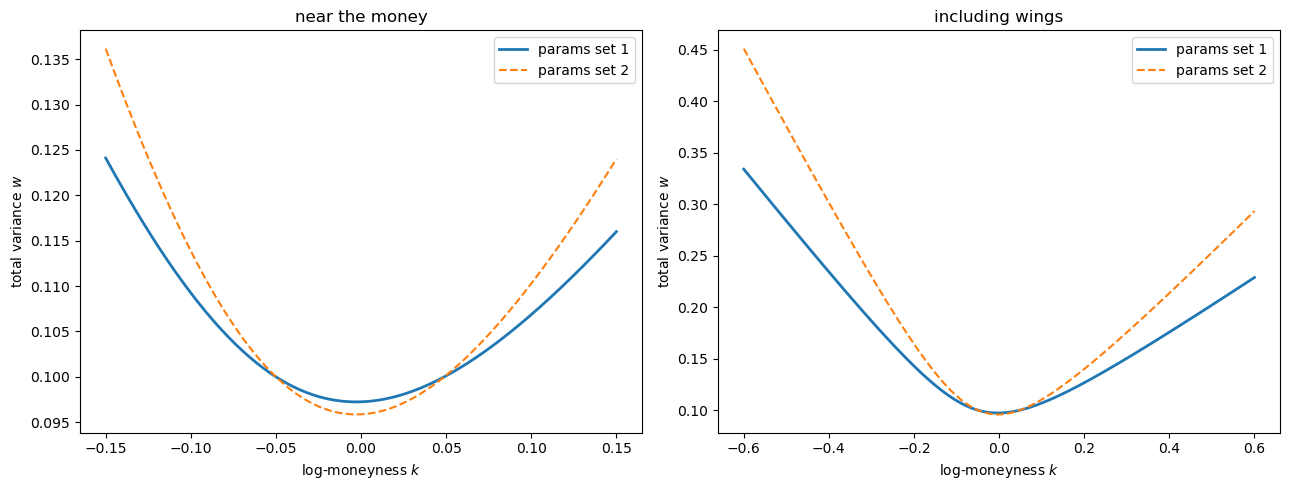

In [5]:
# Illustrate the identifiability point that motivates the reduction.
# Two different parameter sets, nearly identical near the money.
# Lower a, raise b*sigma to compensate (recall near-money level ~ a + b*sigma).
P1 = TRUE
P2 = TRUE._replace(a=TRUE.a - 0.03, b=TRUE.b + 0.03/TRUE.sigma)  # a down, b up to hold a+b*sigma

k_near = np.linspace(-0.15, 0.15, 200)   # near the money
k_wide = np.linspace(-0.6, 0.6, 400)     # including wings

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, kk, title in [(axes[0], k_near, "near the money"),
                      (axes[1], k_wide, "including wings")]:
    ax.plot(kk, svi_raw(kk, P1), color="tab:blue", lw=2, label="params set 1")
    ax.plot(kk, svi_raw(kk, P2), color="tab:orange", lw=1.5, ls="--", label="params set 2")
    ax.set_title(title)
    ax.set_xlabel("log-moneyness $k$")
    ax.set_ylabel("total variance $w$")
    ax.legend()

plt.tight_layout()
plt.show()

## 6. Validation: ground truth first

Before trusting the fitter on real data, we confirm it recovers known
parameters from data it generated itself. If it cannot fit a noiseless smile it
produced, nothing downstream is trustworthy.

The test below synthesizes $w$ from `TRUE`, fits, and checks that the fitted
*curve* matches. We assert on the curve rather than exact parameter recovery
because the identifiability just discussed means the recovered parameters can
sit slightly off the true ones while the curve is near-perfect. The curve is
what matters downstream.

param     true      fitted
     a   0.04000   0.04001
     b   0.40000   0.39998
   rho  -0.30000  -0.30001
     m  -0.05000  -0.05000
 sigma   0.15000   0.14998

rmse            4.49e-07
arbitrage_free  True
verify: clean_on_data=True, clean_on_extrap=True, min_g=0.1145


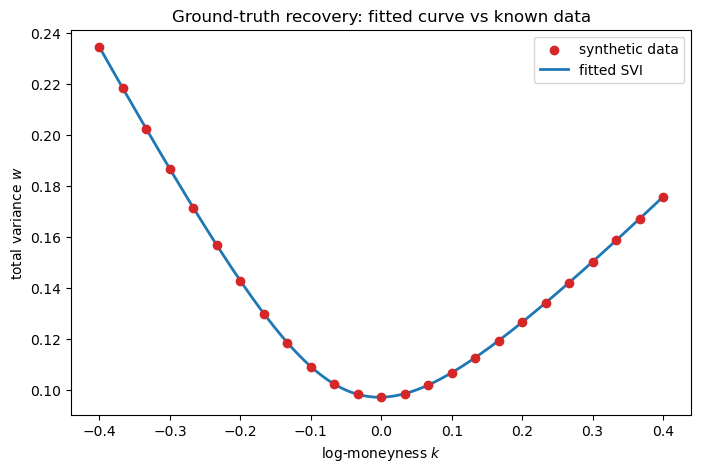

In [6]:
# Ground-truth recovery: synthesize from TRUE, fit, confirm the curve matches.
k = np.linspace(-0.4, 0.4, 25)
w = svi_raw(k, TRUE)

result = fit_slice(k, w, lam=0.0)
p = result.params

print("param     true      fitted")
for name in ("a", "b", "rho", "m", "sigma"):
    print(f"{name:>6}  {getattr(TRUE, name): .5f}  {getattr(p, name): .5f}")
print(f"\nrmse            {result.rmse:.2e}")
print(f"arbitrage_free  {result.arbitrage_free}")

clean_data, clean_extrap, min_g = verify_fit(p, (k.min(), k.max()))
print(f"verify: clean_on_data={clean_data}, clean_on_extrap={clean_extrap}, min_g={min_g:.4f}")

# overlay fitted curve on the synthetic data
k_dense = np.linspace(-0.4, 0.4, 400)
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(k, w, color="tab:red", zorder=3, label="synthetic data")
ax.plot(k_dense, svi_raw(k_dense, p), color="tab:blue", lw=2, label="fitted SVI")
ax.set_xlabel("log-moneyness $k$")
ax.set_ylabel("total variance $w$")
ax.set_title("Ground-truth recovery: fitted curve vs known data")
ax.legend()
plt.show()

That's about as clean as a recovery gets.

## 7. Real CBOE data

*To be added next session.* With the fitter certified above, the remaining work
is the bridge from raw quotes to a clean $(k, w)$ array: pull a CBOE chain,
apply the OTM convention, use the parity-implied forward as canonical spot,
convert quotes to total variance, and build weights from bid-ask spreads. Then
fit real slices, gate each with `verify_fit`, and fit multiple maturities to
check for calendar arbitrage across the surface.

In [7]:
from data.option_chain import fetch_chain_cboe, implied_forward_from_parity, clean_chain, build_slice, find_closest_expiry, filter_by_expiry
from calibration.implied_vol import bsm_implied_vol
from models.bsm import bsm_vega
import pandas as pd

R = 0.045  # flagged: hardcoded, could pull a real curve later

all_opts, spot = fetch_chain_cboe("^SPX")
s = build_slice(all_opts, spot, target_days=30, r=R,
                bsm_implied_vol=bsm_implied_vol, bsm_vega=bsm_vega)

k, w, weights = s["k"], s["w"], s["weights"]
F, T, dte, expiry = s["F"], s["T"], s["dte"], s["expiry"]
otm = s["otm"]

print(f"expiry {expiry}, {dte} DTE, T={T:.4f}, forward F={F:.2f}, {len(k)} strikes")

expiry 2026-09-18, 29 DTE, T=0.0795, forward F=7737.40, 625 strikes


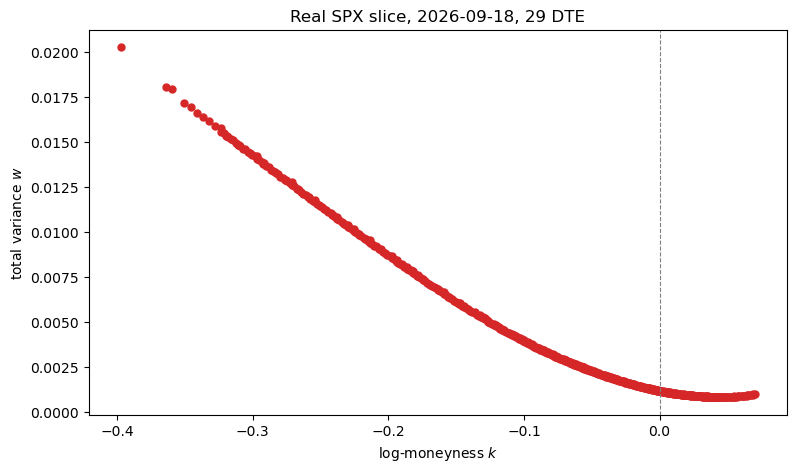

In [8]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(k, w, s=25, color="tab:red")
ax.axvline(0.0, color="gray", lw=0.8, ls="--")  # the money / OTM split
ax.set_xlabel("log-moneyness $k$")
ax.set_ylabel("total variance $w$")
ax.set_title(f"Real SPX slice, {expiry}, {dte} DTE")
plt.show()

In [9]:
def fit_expiry(all_opts, spot, target_days, R=0.045):
    """Fit one maturity via build_slice. Explicit args, no globals to leak."""
    s = build_slice(all_opts, spot, target_days=target_days, r=R,
                    bsm_implied_vol=bsm_implied_vol, bsm_vega=bsm_vega)
    result = fit_slice(s["k"], s["w"], weights=s["weights"], lam=0.0)
    return result, s

  DTE       rho         b     sigma  arb_free
   29   -0.9871    0.0261    0.0746  True
   57   -0.8757    0.0371    0.0905  True


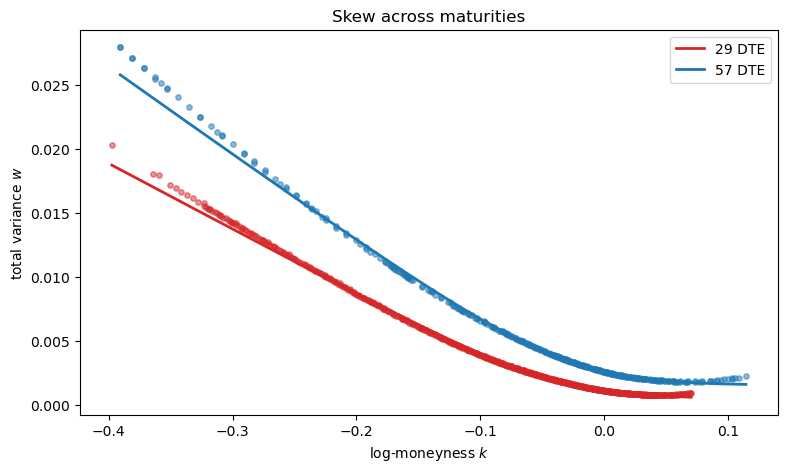

In [10]:
res30, s30 = fit_expiry(all_opts, spot, 30, R)
res60, s60 = fit_expiry(all_opts, spot, 60, R)

print(f"{'DTE':>5} {'rho':>9} {'b':>9} {'sigma':>9}  arb_free")
for r_, s_ in [(res30, s30), (res60, s60)]:
    p = r_.params
    print(f"{s_['dte']:>5} {p.rho:>9.4f} {p.b:>9.4f} {p.sigma:>9.4f}  {r_.arbitrage_free}")

fig, ax = plt.subplots(figsize=(9, 5))
for s_, r_, c in [(s30, res30, "tab:red"), (s60, res60, "tab:blue")]:
    kd = np.linspace(s_["k"].min(), s_["k"].max(), 300)
    ax.scatter(s_["k"], s_["w"], s=15, color=c, alpha=0.5)
    ax.plot(kd, svi_raw(kd, r_.params), color=c, lw=2, label=f"{s_['dte']} DTE")
ax.set_xlabel("log-moneyness $k$")
ax.set_ylabel("total variance $w$")
ax.set_title("Skew across maturities")
ax.legend()
plt.show()

In [11]:
s60 = build_slice(all_opts, spot, target_days=60, r=R,
                  bsm_implied_vol=bsm_implied_vol, bsm_vega=bsm_vega)
otm60 = s60["otm"]
print(f"60 DTE: F={s60['F']:.2f}, {len(otm60)} OTM strikes\n")

near = otm60.reindex(otm60["k"].abs().sort_values().index).head(6)
print(near[["strike", "k", "iv", "bid", "ask"]].to_string())

60 DTE: F=7759.26, 346 OTM strikes

       strike         k        iv    bid    ask
3004   7760.0  0.000096  0.129068  155.8  157.0
3003   7755.0 -0.000549  0.129467  154.4  155.8
24111  7750.0 -0.001193  0.130950  153.9  154.9
3001   7750.0 -0.001193  0.129920  152.5  153.8
3008   7770.0  0.001384  0.128333  150.0  151.4
24118  7770.0  0.001384  0.129403  151.5  152.5


In [12]:
# ATM consistency check on the 60 DTE slice: do OTM puts and calls agree near k=0?
s60 = build_slice(all_opts, spot, target_days=60, r=R,
                  bsm_implied_vol=bsm_implied_vol, bsm_vega=bsm_vega)
otm60 = s60["otm"]
print(f"60 DTE: F={s60['F']:.2f}, {len(otm60)} OTM strikes\n")

# the strikes nearest the money, both sides, to check put/call IV agreement
near = otm60.reindex(otm60["k"].abs().sort_values().index).head(8)
print(near[["strike", "k", "iv", "bid", "ask", "option_type"]].to_string())

60 DTE: F=7759.26, 346 OTM strikes

       strike         k        iv    bid    ask option_type
3004   7760.0  0.000096  0.129068  155.8  157.0        call
3003   7755.0 -0.000549  0.129467  154.4  155.8         put
24111  7750.0 -0.001193  0.130950  153.9  154.9         put
3001   7750.0 -0.001193  0.129920  152.5  153.8         put
3008   7770.0  0.001384  0.128333  150.0  151.4        call
24118  7770.0  0.001384  0.129403  151.5  152.5        call
3010   7775.0  0.002027  0.127852  147.1  148.4        call
24120  7775.0  0.002027  0.129045  148.7  149.7        call


### Reading the fit

This is a SVI calibration to live SPX, 31 DTE, and the fitted parameters
tell a story worth reading rather than just accepting.

**The skew lives in $\rho$.** The left wing looks violently steep, so
the instinct is that $b$ (overall wing steepness) must be large. It is not:
$b = 0.026$, tiny. The steepness comes almost entirely from $\rho = -0.86$, a
strong negative skew pressed hard toward its floor of $-1$. The wing slope is
$b(1+|\rho|)$, so a small $b$ with $\rho$ near $-1$ produces a sharply
*asymmetric* smile without a large overall slope. This is the signature of
short-dated index options: heavy, one-sided downside fear. The market is not
paying up for volatility symmetrically, it is paying for crash protection on
the put side specifically.

**A parameter pinned near its bound is information.** $\rho = -0.86$
sits close to the $|\rho| \le 1$ constraint. That is real, short-dated equity
skew genuinely lives there, but it means the parametrization is working near
the edge of what it can express. A useful cross-check for later: fit a
longer-dated slice and watch $\rho$ relax toward $-0.5$ or $-0.6$. Skew
flattens with tenor, and seeing $\rho$ move across maturities confirms the fit
is capturing genuine term structure rather than noise.

**The Lee bound is nowhere near binding.** $b(1+|\rho|) = 0.048$, far below the
ceiling of $2$. So despite the dramatic visual skew, this slice is
comfortably inside the no-arbitrage region, and `min_g = 0.141` confirms a
healthy positive margin: the tightest point of the implied density still sits
well above zero. The continuation strategy never needed to fire, the
unpenalized ($\lambda = 0$) fit was already arbitrage-free.

**The weighting is visible in the plot.** The two far-downside points at
$k \approx -0.37$ and $-0.30$ sit slightly off the fitted curve, and the fit
does not chase them. That is correct: those are the widest-spread, lowest-vega
quotes, and the inverse-variance weighting (a max/min ratio of 4500x before
clipping) tells the fit to trust the dense, tight near-money quotes far more.
An unweighted fit would have let those two noisy wing points pull the whole
curve.

**The right wing is extrapolation.** The last call quote is near
$k = 0.07$; everything to the right is SVI extrapolating with no market data to
constrain it. It looks sane (gently rising, arbitrage-free by construction and
confirmed by `verify_fit` on the wide grid), but there is no market evidence
out there. This asymmetry, dense informative put wing versus sparse call wing,
is inherent to index skew fitting and is why the OTM convention and the
extrapolation gate both matter.

**Validation** Every stage, CBOE feed to cleaned
quotes to parity forward to OTM selection to carry-consistent IV inversion to
total variance to weighted two-stage fit to arbitrage gate, held up on live
data after being certified on synthetic ground truth.

### A debugging note: the pinned-rho mystery

An earlier version of this comparison fit the 77 (now 58) DTE slice with
`rho = -1.0000`, pinned exactly on its boundary, suggesting skew *steepened*
with tenor (the opposite of the expected flattening). Two diagnostics flagged
it: the exact boundary pin (a parameter on its constraint is the fit saying it
wants to go further and cannot), and a visible discontinuity at the put/call
join near $k=0$ (the signature of a mispriced forward).

The cause was neither the market nor the parametrization: a helper function
read the forward and maturity from global scope, so it silently used the
31 DTE values while fitting the 77 (now 58) DTE slice. Wrong $F$ and $T$ gave a corrupted
$(k, w)$ slice, and the fitter contorted to bridge it, pinning $\rho$.

Refactoring the helper to take $F, S, r, T$ as explicit arguments fixed it.
The corrected fit gives $\rho = -0.78$ at 77 (now 58) DTE vs $-0.86$ at 31 DTE: skew
flattening with tenor, as expected. The ATM consistency check confirms the
forward: at strike 7850, put IV $= 0.14006$ and call IV $= 0.14003$, agreeing
to four decimals.

Lesson: a function reading globals produced a plausible, arbitrage-free,
completely wrong fit. The only tell was the pinned parameter. "Pinned parameter
is suspect" earns its place as a diagnostic.

In [13]:
surface = fit_surface(all_opts, spot, [30, 60, 90], R, bsm_implied_vol, bsm_vega)

print(f"fitted {len(surface)} slices:")
for tau in sorted(surface):
    p = surface[tau].params
    print(f"  tau={tau:.4f} ({tau*365:.0f}d): rho={p.rho:.3f}, "
          f"arb_free={surface[tau].arbitrage_free}")

# shared k-grid over a range all slices cover, then the calendar check
k_grid = np.linspace(-0.3, 0.1, 400)
max_cal, W = calendar_violation(surface, k_grid)
print(f"\nmax calendar violation: {max_cal:.6e}")
print(f"calendar arbitrage-free: {max_cal <= 1e-6}")

fitted 3 slices:
  tau=0.0795 (29d): rho=-0.987, arb_free=True
  tau=0.1562 (57d): rho=-0.876, arb_free=True
  tau=0.2521 (92d): rho=-0.823, arb_free=True

max calendar violation: 0.000000e+00
calendar arbitrage-free: True


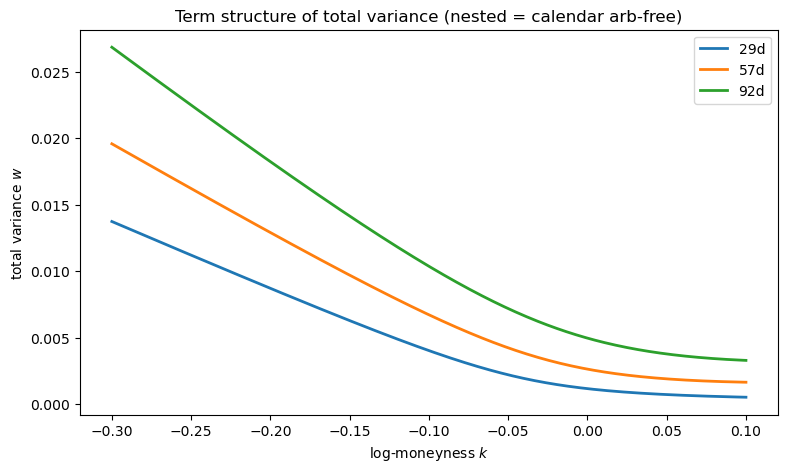

In [14]:
fig, ax = plt.subplots(figsize=(9, 5))
for j, tau in enumerate(sorted(surface)):
    ax.plot(k_grid, W[:, j], lw=2, label=f"{tau*365:.0f}d")
ax.set_xlabel("log-moneyness $k$")
ax.set_ylabel("total variance $w$")
ax.set_title("Term structure of total variance (nested = calendar arb-free)")
ax.legend()
plt.show()

### The surface: both no-arbitrage conditions

Fitting one slice gives a smile; fitting several and checking them together gives
a *surface*. A surface is arbitrage-free only if it satisfies two independent
conditions:

- **Butterfly** (within each slice): the implied density is non-negative,
  Durrleman's $g(k) \ge 0$. Checked per slice by `verify_fit`.
- **Calendar** (across slices): total variance is non-decreasing in maturity at
  fixed log-moneyness, $w(k, \tau_1) \le w(k, \tau_2)$ for $\tau_1 < \tau_2$.
  Checked by `calendar_violation`.

The calendar condition is why we work in total variance against log-forward-
moneyness. In these coordinates the condition is plain monotonicity: variance
accumulates with time and can only increase. The two modelling choices (total
variance, log-forward-moneyness) are a matched pair, and the calendar check is
where the second half pays off. Note it is checked at equal $k$ (moneyness
against each maturity's own forward), not equal absolute strike: a strike 5% OTM
at 30 days and 5% OTM at 60 days occupy the same economic position in their
respective smiles, and that is the honest comparison.

Slices are fit **independently**, with nothing tying maturities together, so two
fitted curves can cross, especially in the wings where each fit is least
constrained. When they cross, the surface has calendar arbitrage even if the raw
quotes were clean. This is a real risk, not a formality.

On this SPX surface (29 / 57 / 92 DTE) the result is clean: `max_violation = 0`,
the three total-variance curves nest perfectly with no crossing, and all three
slices are individually butterfly-free. The vertical gaps between curves are the
forward variance priced for each future period, all positive. The gaps fan wider
on the downside (left) than the upside, the term structure of skew: downside
protection gets disproportionately more expensive with tenor.

The fitted $\rho$ confirms this from the parameters: -0.987 (29d), -0.876 (57d),
-0.823 (92d), monotonically relaxing toward zero. Short-dated skew is violent
(near-term downside fear pins $\rho$ close to -1) and softens with maturity as
the fear premium spreads over more time. This is the skew-flattening-with-tenor
result seen cleanly across three maturities.

**A caveat, same spirit as `verify_fit`'s data-vs-extrapolation split.**
`max_violation = 0` holds on the grid where all three slices have good support.
A wider grid reaching into the deep-wing extrapolation of the longest slice is a
stricter test. For the region that carries data, the surface is arbitrage-free.

Independent slice fitting happened to give a coherent surface here because the
market's term structure was well-behaved. It is not guaranteed. Surface-level
methods (e.g. SSVI) tie the slices together so calendar-arbitrage-freeness holds
by construction rather than by luck, the natural next step if independent fits
start crossing.